In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from google.colab import drive
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import interp1d

Import data

In [ ]:
vd_df = pd.read_excel('./ViralDynamicsData_Publication.xlsx')

# Keep only treated individuals and sort for piecewise simulation
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])
# Load parameter tables
params_df_A1 = pd.read_csv("./estimatedIndividualParameters_A1.txt", sep=',')
params_df_A2 = pd.read_csv("./estimatedIndividualParameters_A2.txt", sep=',')
params_df_A3 = pd.read_csv("./estimatedIndividualParameters_A3.txt", sep=',')
params_df_A4T = pd.read_csv("./estimatedIndividualParameters_A4T.txt", sep=',')

Global constants and functions

In [ ]:
TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

In [ ]:
# 1. Global Parameters & Constants

PK_CONSTANTS = {
   "A1": {"MolMass": 602.58, "Volume": 3690},
   "A2": {"MolMass": 442.32, "Volume": 30446.12},
   "A3": {"MolMass": 291.26, "Volume": 924.6},
   "A4T": {"MolMass": 531.2, "Volume": 1000000}
}

PD_PARAMS = {
   "Emax": 0.99,
   "Hill": 1,
   "c": 15,
   "k": 4,
   "F": 1_000_000
}

# Fixed PK Parameters
FIXED_PK = {
    "k12":22.525296,
    "k23":0.6,
    "kcl1":0.000864,
    "kcl2":9.6,
    "kcl3":6,
    "kcl4":1.0824,
    "k1pt":319.2,
    "k1tp":3.12,
    "k2pt":10.32,
    "k2tp":0.01296,
    "k3tp":0.036,
    "k3pt":1.08,
    "k34":6
}

In [ ]:
# 2. ODE Model System

def viral_dynamic_model(t, y, target_cpt, params, dynamic_inputs):
  """
  Combined PK/PD and Viral Dynamics ODE system.
  """
  A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y

  # Unpack dynamic input
  treatment = dynamic_inputs['treatment']

  # Unpack VD parameters
  beta = params['beta']
  pi = params['pi']
  rho = params['rho']
  phi = params['phi']
  delta = params['delta']
  m = params['m']
  tau = params['tau']
  IC50 = params['IC50']

  # --- PK Model ---
  ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1

  ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2

  ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2

  ddt_A1T = (FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T)

  ddt_A2T = (FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T)

  ddt_A3T = (-FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T)

  ddt_A4T = (FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T)

  # --- PD Effect (epsilon) ---
  # Calculate Concentration based on target compartment
  if target_cpt == "A1":
      Cc = A1 / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
  elif target_cpt == "A2":
      Cc = A2 / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
  elif target_cpt == "A3":
      Cc = A3 / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
  elif target_cpt == "A4T":
      Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])
  else:
      Cc = 0

  if treatment == 0:
      epsilon = 0
  else:
      # Prevent division by zero
      if Cc <= 0:
          epsilon = 0
      else:
          epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

  # --- Viral Dynamics ---
  eps = m if t > tau else 0

  ddt_T = -beta * T * V - phi * I * T + rho * R
  ddt_R = phi * I * T - rho * R
  ddt_E = beta * T * V - PD_PARAMS['k'] * E
  ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I

  # Enforce that infected cells do not produce virus until there is at least 1
  if I >= 1:
      temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V
  else:
      temp = -PD_PARAMS['c'] * V

  ddt_V = temp

  return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

In [ ]:
# 3. Simulation Engine

def simulate_patient(patient_id, target_cpt, data_df, param_df):
  """
  Simulates the VD model for a specific patient and a specific target compartment.
  """
  # 1. Extract Individual VD Parameters
  p_row = param_df[param_df['id'] == patient_id].iloc[0]

  params = {
      'beta': 10 ** p_row['log10beta_mode'],
      'pi': 10 ** p_row['log10pi_mode'],
      'rho': 10 ** p_row['log10rho_mode'],
      'phi': 10 ** p_row['log10phi_mode'],
      'delta': p_row['delta_mode'],
      'm': p_row['m_mode'],
      'tau': p_row['tau_mode'],
      'tzero': p_row['tzero_mode'],
      'Vzero': p_row['Vzero_mode'],
      'IC50': p_row['IC50_mode']
  }

  # 2. Extract Patient Data/Events
  pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

  # Initial Conditions (at t = -tzero)
  # y = [A1, A1T, A2, A2T, A3, A3T, T, R, E, I, V]
  y0 = [0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
  t_start = -params['tzero']

  # Prepare arrays to collect results
  t_out = []
  y_out = []

  current_time = t_start

  # Track the active PK/PD covariates
  first_record = pt_data.iloc[0]
  active_inputs = {
      'treatment': first_record['treatment']
  }

  # 3. Piecewise Integration over Data Events
  for idx, row in pt_data.iterrows():
      t_event = row['time']

      # If the event is in the future relative to our current simulated time, integrate up to it
      if t_event > current_time:
          t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))

          sol = solve_ivp(
              fun=viral_dynamic_model,
              t_span=(current_time, t_event),
              y0=y0,
              t_eval=t_eval,
              args=(target_cpt, params, active_inputs),
              method='LSODA',
              max_step=0.1
          )

          t_out.append(sol.t)
          y_out.append(sol.y)

          # Update initial conditions for the next segment
          y0 = sol.y[:, -1]
          current_time = t_event

      # Apply dose at this event time
      dose_mg = row['Amnt_mg']
      if pd.notna(dose_mg) and dose_mg > 0:
          y0[0] += dose_mg * PD_PARAMS['F']  # Add to A1

      # Update Regressors for future integrations
      active_inputs['treatment'] = row['treatment']

  # Simulate a few days past the last data point to see the tail
  t_final = current_time + 10
  t_eval = np.linspace(current_time, t_final, 500)
  sol = solve_ivp(
      fun=viral_dynamic_model,
      t_span=(current_time, t_final),
      y0=y0,
      t_eval=t_eval,
      args=(target_cpt, params, active_inputs),
      method='LSODA'
  )
  t_out.append(sol.t)
  y_out.append(sol.y)

  # Stitch arrays
  t_sim = np.concatenate(t_out)
  y_sim = np.concatenate(y_out, axis=1)

  # Extract Viral Load and apply LLOQ logic
  V_sim = y_sim[10, :]
  V_sim = np.where(V_sim < 200, 100, V_sim) # Values < LLOQ get imputed to 100 copies/mL
  log10V_sim = np.log10(V_sim)

  return t_sim, log10V_sim

Fig 3a. Simulated PK Model vs solved in vivo EC50 and estimated drug efficacy over time

In [ ]:
def get_average_epsilons_for_treatment(data_df, param_A1, param_A2, param_A3, param_A4T):
    """
    Loops through all patients, runs the PK/PD simulation, and calculates
    the time-averaged epsilon AND the time-averaged mass concentration
    (ng/mL) for each compartment, ONLY during the treatment course
    (up to the 7th row).

    - Reported concentrations (Avg_Conc_ngmL) are mass concentration: amt / Volume.
    - Epsilon is still computed from the molar-equivalent concentration:
      amt / (Volume * MolMass), matched against IC50 (assumed molar units),
      since that's the quantity the Hill equation needs.
    """
    patient_ids = data_df['ID'].unique()
    results = []

    print(f"Simulating {len(patient_ids)} patients to calculate average epsilon...")

    for pid in patient_ids:
        pt_data = data_df[data_df['ID'] == pid].sort_values(by='time').copy()

        IC50_A1 = param_A1[param_A1['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A2 = param_A2[param_A2['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A3 = param_A3[param_A3['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A4T = param_A4T[param_A4T['id'] == pid]['IC50_mode'].iloc[0]

        # [A1, A1T, A2, A2T, A3, A3T, A4T]
        y0 = [0, 0, 0, 0, 0, 0, 0]
        t_start = pt_data['time'].min()
        current_time = t_start

        t_out, y_out = [], []

        # Piecewise Integration
        for idx, row in pt_data.iterrows():
            t_event = row['time']
            if t_event > current_time:
                t_eval = np.linspace(current_time, t_event, 100)
                sol = solve_ivp(
                    fun=pk_model_only, t_span=(current_time, t_event), y0=y0,
                    t_eval=t_eval, method='LSODA'
                )
                t_out.append(sol.t)
                y_out.append(sol.y)
                y0 = sol.y[:, -1]
                current_time = t_event

            dose_mg = row['Amnt_mg']
            if pd.notna(dose_mg) and dose_mg > 0:
                y0[0] += dose_mg * PD_PARAMS['F']  # instantaneous bolus

        # Simulate final tail (1 day post-last event)
        t_final = current_time + 1
        t_eval = np.linspace(current_time, t_final, 100)
        sol = solve_ivp(
            fun=pk_model_only, t_span=(current_time, t_final), y0=y0,
            t_eval=t_eval, method='LSODA'
        )
        t_out.append(sol.t)
        y_out.append(sol.y)

        t_sim = np.concatenate(t_out)
        y_sim = np.concatenate(y_out, axis=1)
        A1_arr, _, A2_arr, _, A3_arr, _, A4T_arr = y_sim

        # Mass concentration (ng/mL)
        c_ng_A1 = A1_arr / PK_CONSTANTS["A1"]["Volume"]
        c_ng_A2 = A2_arr / PK_CONSTANTS["A2"]["Volume"]
        c_ng_A3 = A3_arr / PK_CONSTANTS["A3"]["Volume"]
        c_ng_A4T = A4T_arr / PK_CONSTANTS["A4T"]["Volume"]

        # Molar-equivalent concentration: used ONLY for epsilon
        cc_molar_A1 = A1_arr / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
        cc_molar_A2 = A2_arr / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
        cc_molar_A3 = A3_arr / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
        cc_molar_A4T = A4T_arr / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])

        eps_A1 = PD_PARAMS["Emax"] * (cc_molar_A1**PD_PARAMS["Hill"]) / ((cc_molar_A1**PD_PARAMS["Hill"]) + (IC50_A1**PD_PARAMS["Hill"]))
        eps_A2 = PD_PARAMS["Emax"] * (cc_molar_A2**PD_PARAMS["Hill"]) / ((cc_molar_A2**PD_PARAMS["Hill"]) + (IC50_A2**PD_PARAMS["Hill"]))
        eps_A3 = PD_PARAMS["Emax"] * (cc_molar_A3**PD_PARAMS["Hill"]) / ((cc_molar_A3**PD_PARAMS["Hill"]) + (IC50_A3**PD_PARAMS["Hill"]))
        eps_A4T = PD_PARAMS["Emax"] * (cc_molar_A4T**PD_PARAMS["Hill"]) / ((cc_molar_A4T**PD_PARAMS["Hill"]) + (IC50_A4T**PD_PARAMS["Hill"]))

        # Cutoff time: time of the 7th row (index 6), with fallback
        if len(pt_data) >= 7:
            t_cutoff = pt_data.iloc[6]['time']
        else:
            t_cutoff = t_sim[-1]

        treat_mask = t_sim <= t_cutoff
        t_sim_treat = t_sim[treat_mask]

        eps_A1_treat = eps_A1[treat_mask]
        eps_A2_treat = eps_A2[treat_mask]
        eps_A3_treat = eps_A3[treat_mask]
        eps_A4T_treat = eps_A4T[treat_mask]

        c_ng_A1_treat = c_ng_A1[treat_mask]
        c_ng_A2_treat = c_ng_A2[treat_mask]
        c_ng_A3_treat = c_ng_A3[treat_mask]
        c_ng_A4T_treat = c_ng_A4T[treat_mask]

        treat_time = t_sim_treat[-1] - t_sim_treat[0]

        if treat_time > 0:
            avg_eps_A1 = np.trapz(eps_A1_treat, t_sim_treat) / treat_time
            avg_eps_A2 = np.trapz(eps_A2_treat, t_sim_treat) / treat_time
            avg_eps_A3 = np.trapz(eps_A3_treat, t_sim_treat) / treat_time
            avg_eps_A4T = np.trapz(eps_A4T_treat, t_sim_treat) / treat_time

            avg_conc_A1 = np.trapz(c_ng_A1_treat, t_sim_treat) / treat_time
            avg_conc_A2 = np.trapz(c_ng_A2_treat, t_sim_treat) / treat_time
            avg_conc_A3 = np.trapz(c_ng_A3_treat, t_sim_treat) / treat_time
            avg_conc_A4T = np.trapz(c_ng_A4T_treat, t_sim_treat) / treat_time
        else:
            avg_eps_A1 = avg_eps_A2 = avg_eps_A3 = avg_eps_A4T = 0.0
            avg_conc_A1 = avg_conc_A2 = avg_conc_A3 = avg_conc_A4T = 0.0

        results.append({"ID": pid, "Compartment": "A1 (GS-5734)",   "Avg_Epsilon": avg_eps_A1, "Avg_Conc_ngmL": avg_conc_A1})
        results.append({"ID": pid, "Compartment": "A2 (GS-704277)", "Avg_Epsilon": avg_eps_A2, "Avg_Conc_ngmL": avg_conc_A2})
        results.append({"ID": pid, "Compartment": "A3 (GS-441524)", "Avg_Epsilon": avg_eps_A3, "Avg_Conc_ngmL": avg_conc_A3})
        results.append({"ID": pid, "Compartment": "A4T (GS-443902)","Avg_Epsilon": avg_eps_A4T, "Avg_Conc_ngmL": avg_conc_A4T})

    return pd.DataFrame(results)

In [ ]:
def pk_model_only(t, y):
    A1, A1T, A2, A2T, A3, A3T, A4T = y
    A3_safe = max(A3, 0.0)
    ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
    ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T
    ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2
    ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T
    ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2
    ddt_A3T = -FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T
    ddt_A4T = FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T]

In [ ]:
# 2. Synchronized Nominal Simulation Engine
def simulate_nominal_patient(patient_id, data_df, param_A1, param_A2, param_A3, param_A4T, t_eval_grid):
    """
    Simulates a patient's specific biology under a strict nominal schedule to allow
    perfect cross-sectional matrix aggregation without peak smearing.
    """
    pt_data = data_df[data_df['ID'] == patient_id].copy()

    # Extract baseline biological parameters safely
    IC50_A1 = param_A1[param_A1['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A2 = param_A2[param_A2['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A3 = param_A3[param_A3['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A4T = param_A4T[param_A4T['id'] == patient_id]['IC50_mode'].values[0]

    # Strict Nominal Schedule: (Time_in_Days, Dose_mg)
    nominal_schedule = [(0.0, 200.0), (1.0, 100.0), (2.0, 100.0), (3.0, 100.0), (4.0, 100.0)]

    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    # Integrate strictly between synchronized regimen boundaries
    for t_event, dose_mg in nominal_schedule:
        # Apply absolute dose bolus instantly to A1
        y0[0] += dose_mg * PD_PARAMS['F']

        next_time = t_event + 1.0
        # Inject an extremely dense sub-grid immediately post-bolus to resolve Cmax perfectly
        t_dense = np.concatenate([
            np.linspace(current_time, current_time + 0.01, 50),  # First 14 mins post-dose
            np.linspace(current_time + 0.01, next_time, 150)
        ])

        sol = solve_ivp(
            fun=pk_model_only, t_span=(current_time, next_time), y0=y0,
            t_eval=np.unique(t_dense), method='LSODA'
        )
        t_out.append(sol.t[:-1])
        y_out.append(sol.y[:, :-1])
        y0 = sol.y[:, -1]
        current_time = next_time

    # 5-Day Washout Phase
    t_tail = np.linspace(current_time, current_time + 5.0, 500)
    sol_tail = solve_ivp(
        fun=pk_model_only, t_span=(current_time, current_time + 5.0), y0=y0,
        t_eval=t_tail, method='LSODA'
    )
    t_out.append(sol_tail.t)
    y_out.append(sol_tail.y)

    t_raw = np.concatenate(t_out)
    y_raw = np.concatenate(y_out, axis=1)

    # Process core outputs
    concs, epsilons = {}, {}
    ic50_ngml = {}

    # State indices for the target compartments:
    # A1 = index 0, A2 = index 2, A3 = index 4, A4T = index 6
    target_comps = [("A1", 0, IC50_A1), ("A2", 2, IC50_A2), ("A3", 4, IC50_A3), ("A4T", 6, IC50_A4T)]

    for comp, idx, ic50_val in target_comps:
        amt = y_raw[idx]
        vol = PK_CONSTANTS[comp]["Volume"]
        mass = PK_CONSTANTS[comp]["MolMass"]

        c_ng = amt / vol
        ic50_ngml[comp] = ic50_val * mass
        cc = amt / (vol * mass)
        eps = PD_PARAMS["Emax"] * (cc**PD_PARAMS["Hill"]) / ((cc**PD_PARAMS["Hill"]) + (ic50_val**PD_PARAMS["Hill"]))

        # Interpolate onto the exact requested evaluation grid
        f_c = interp1d(t_raw, c_ng, bounds_error=False, fill_value=(0.0, 0.0))
        f_e = interp1d(t_raw, eps, bounds_error=False, fill_value=(0.0, 0.0))
        concs[comp] = f_c(t_eval_grid)
        epsilons[comp] = f_e(t_eval_grid)

    return concs, epsilons, ic50_ngml

In [ ]:
def generate_aligned_baseline_dashboard(patient_id_array, data_df, param_A1, param_A2, param_A3, param_A4T):

    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.titlesize': MEDIUM_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'axes.titleweight': 'normal'
    })

    # Time grid
    base_grid = np.linspace(0, 10, 2000)
    injection_points = np.array([0.0, 0.001, 0.005, 1.0, 1.001, 2.0, 2.001, 3.0, 3.001, 4.0, 4.001])
    t_aligned = np.unique(np.sort(np.concatenate([base_grid, injection_points])))

    pop_concs = {"A1": [], "A2": [], "A3": [], "A4T": []}
    pop_eps = {"A1": [], "A2": [], "A3": [], "A4T": []}
    pop_ic50s = {"A1": [], "A2": [], "A3": [], "A4T": []}

    for pt_id in patient_id_array:
        c_map, e_map, ic50_map = simulate_nominal_patient(
            pt_id, data_df, param_A1, param_A2, param_A3, param_A4T, t_aligned
        )
        for comp in ["A1", "A2", "A3", "A4T"]:
            pop_concs[comp].append(c_map[comp])
            pop_eps[comp].append(e_map[comp])
            pop_ic50s[comp].append(ic50_map[comp])

    # Convert to arrays
    for comp in ["A1", "A2", "A3", "A4T"]:
        pop_concs[comp] = np.array(pop_concs[comp])
        pop_eps[comp] = np.array(pop_eps[comp])
        pop_ic50s[comp] = np.array(pop_ic50s[comp])

    fig, axes = plt.subplots(2, 4, figsize=(5.0, 2.6), dpi=300, sharex=True)

    colors = {"A1": "navy", "A2": "firebrick", "A3": "darkgreen", "A4T": "orange"}
    titles = {"A1": "GS-5734", "A2": "GS-704277", "A3": "GS-441524", "A4T": "GS-443902"}

    for i, comp in enumerate(["A1", "A2", "A3", "A4T"]):

        med_c = np.median(pop_concs[comp], axis=0)
        med_e = np.median(pop_eps[comp], axis=0)
        med_ic50 = np.median(pop_ic50s[comp])

        ax_c = axes[0, i]
        ax_c.plot(t_aligned, med_c, color=colors[comp], linewidth=1.2)
        ax_c.axhline(y=med_ic50, color='black', linestyle='--', linewidth=0.9)

        ax_c.set_title(titles[comp])

        if i == 0:
            ax_c.set_ylabel("Concentration\n(ng/mL)")
            # Set the lower y-axis limit to 10^-8 for A1
            ax_c.set_ylim(bottom=1e-8)

        ax_c.set_yscale('log')
        ax_c.grid(True, alpha=0.25)

        if comp in ["A3", "A4T"]:
            ax_c.text(9.8, med_ic50, 'IC50', fontsize=TINY_SIZE,
                      verticalalignment='top', horizontalalignment='right')
        else:
            ax_c.text(9.8, med_ic50, 'IC50', fontsize=TINY_SIZE,
                      verticalalignment='bottom', horizontalalignment='right')

        ax_c.set_xlim(-0.2, 10.2)

        ax_e = axes[1, i]
        ax_e.plot(t_aligned, med_e, color=colors[comp], linewidth=1.2)

        if i == 0:
            ax_e.set_ylabel(r"Efficacy")

        ax_e.set_xlabel("Time (days)")
        ax_e.set_ylim(0.0, 1.05)

        ax_e.grid(True, alpha=0.25)
        ax_e.xaxis.set_major_locator(MultipleLocator(5))

    plt.tight_layout(pad=0.3, w_pad=0.2, h_pad=0.2)

    plt.show()

    plt.rcdefaults()

    return t_aligned, pop_concs, pop_eps

In [ ]:
# patients who actually received Remdesivir (treatment == 1)
treated_patients = vd_df[vd_df['treatment'] == 1]['ID'].unique()

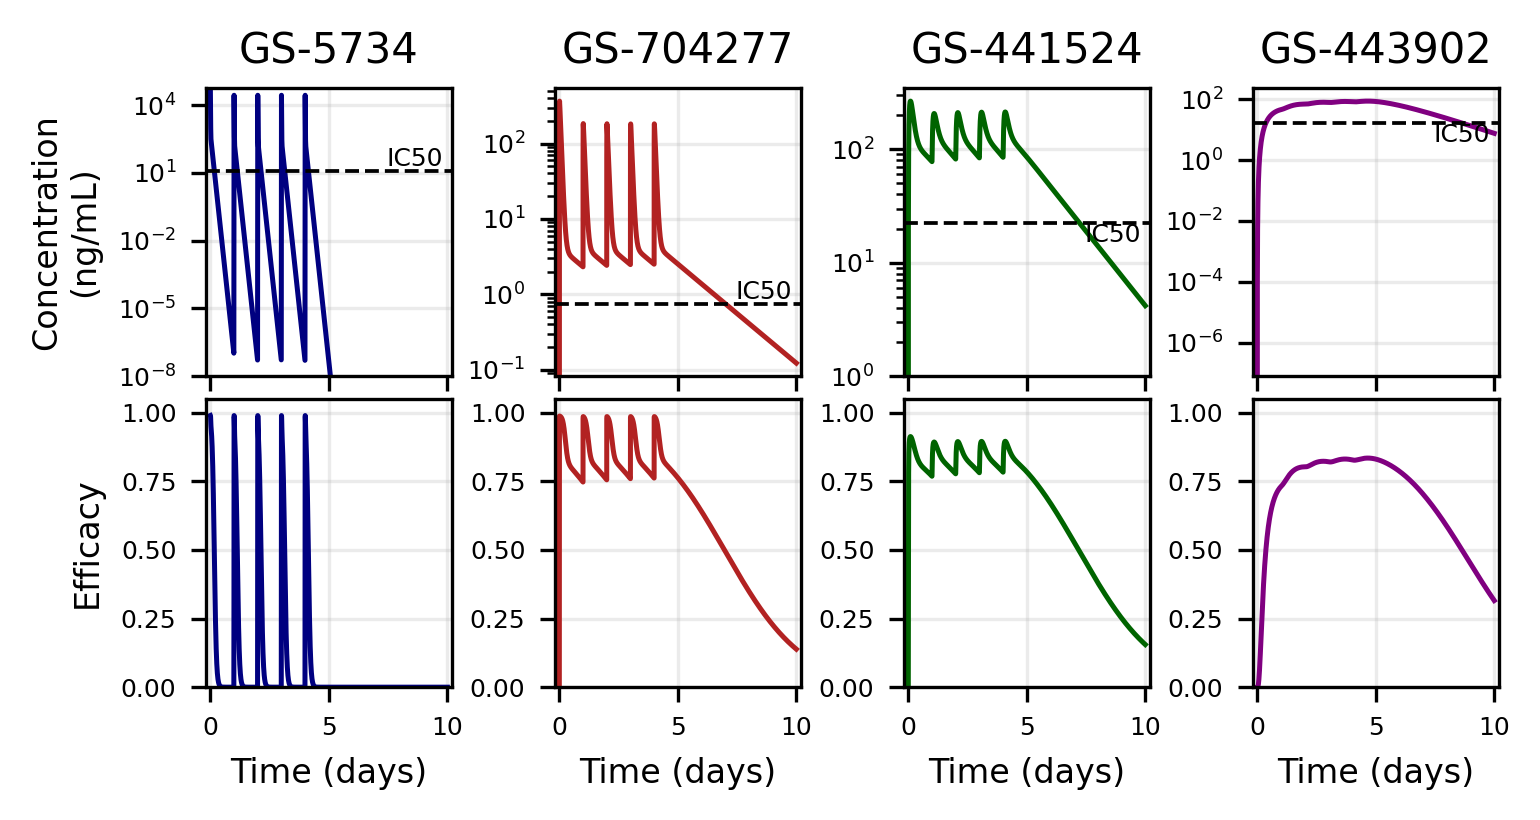

In [ ]:
t_grid, final_concs, final_eps = generate_aligned_baseline_dashboard(
    treated_patients, vd_df, params_df_A1, params_df_A2, params_df_A3, params_df_A4T
)

Fig 3b. Time averaged epsilon comparisons across 4 compartments

In [ ]:
# Calculate average epsilon only over the timeframe of drug administration
def get_average_epsilons_for_treatment(data_df, param_A1, param_A2, param_A3, param_A4T):
    """
    Loops through all patients, runs the PK/PD simulation, and calculates
    the time-averaged epsilon for each compartment ONLY during the
    treatment course (up to the 7th row).
    """
    patient_ids = data_df['ID'].unique()
    results = []

    print(f"Simulating {len(patient_ids)} patients to calculate average epsilon...")

    for pid in patient_ids:
        # Filter data for the specific patient
        pt_data = data_df[data_df['ID'] == pid].sort_values(by='time').copy()

        # Extract IC50_mode for each compartment for this patient
        IC50_A1 = param_A1[param_A1['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A2 = param_A2[param_A2['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A3 = param_A3[param_A3['id'] == pid]['IC50_mode'].iloc[0]
        IC50_A4T = param_A4T[param_A4T['id'] == pid]['IC50_mode'].iloc[0]

        # Initialize simulation states
        y0 = [0, 0, 0, 0, 0, 0, 0] # [A1, A1T, A2, A2T, A3, A3T, A4T]
        t_start = pt_data['time'].min()
        current_time = t_start

        t_out, y_out = [], []

        # Piecewise Integration
        for idx, row in pt_data.iterrows():
            t_event = row['time']
            if t_event > current_time:
                t_eval = np.linspace(current_time, t_event, 100)
                sol = solve_ivp(
                    fun=pk_model_only, t_span=(current_time, t_event), y0=y0,
                    t_eval=t_eval, method='LSODA'
                )
                t_out.append(sol.t)
                y_out.append(sol.y)
                y0 = sol.y[:, -1]
                current_time = t_event

            dose_mg = row['Amnt_mg']
            if pd.notna(dose_mg) and dose_mg > 0:
                y0[0] += dose_mg * PD_PARAMS['F']

        # Simulate final tail (currently set to 1 day post-last event)
        t_final = current_time + 1
        t_eval = np.linspace(current_time, t_final, 100)
        sol = solve_ivp(
            fun=pk_model_only, t_span=(current_time, t_final), y0=y0,
            t_eval=t_eval, method='LSODA'
        )
        t_out.append(sol.t)
        y_out.append(sol.y)

        # Combine results
        t_sim = np.concatenate(t_out)
        y_sim = np.concatenate(y_out, axis=1)

        # Unpack the 7 states
        A1_arr, _, A2_arr, _, A3_arr, _, A4T_arr = y_sim

        # Calculate Epsilon
        Cc_A1 = A1_arr / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
        Cc_A2 = A2_arr / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
        Cc_A3 = A3_arr / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
        Cc_A4T = A4T_arr / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])

        eps_A1 = PD_PARAMS["Emax"] * (Cc_A1**PD_PARAMS["Hill"]) / ((Cc_A1**PD_PARAMS["Hill"]) + (IC50_A1**PD_PARAMS["Hill"]))
        eps_A2 = PD_PARAMS["Emax"] * (Cc_A2**PD_PARAMS["Hill"]) / ((Cc_A2**PD_PARAMS["Hill"]) + (IC50_A2**PD_PARAMS["Hill"]))
        eps_A3 = PD_PARAMS["Emax"] * (Cc_A3**PD_PARAMS["Hill"]) / ((Cc_A3**PD_PARAMS["Hill"]) + (IC50_A3**PD_PARAMS["Hill"]))
        eps_A4T = PD_PARAMS["Emax"] * (Cc_A4T**PD_PARAMS["Hill"]) / ((Cc_A4T**PD_PARAMS["Hill"]) + (IC50_A4T**PD_PARAMS["Hill"]))

        # 1. Define the cutoff time (time of the 7th row, which is index 6).
        if len(pt_data) >= 7:
            t_cutoff = pt_data.iloc[6]['time']
        else:
            t_cutoff = t_sim[-1]

        # 2. Create a boolean mask to isolate the treatment window
        treat_mask = t_sim <= t_cutoff

        # 3. Apply the mask to time and epsilon arrays
        t_sim_treat = t_sim[treat_mask]
        eps_A1_treat = eps_A1[treat_mask]
        eps_A2_treat = eps_A2[treat_mask]
        eps_A3_treat = eps_A3[treat_mask]
        eps_A4T_treat = eps_A4T[treat_mask]

        # 4. Calculate Time-Averaged Epsilon (AUC / Treatment Time)
        treat_time = t_sim_treat[-1] - t_sim_treat[0]

        # Handle edge case where treat_time might be 0 to avoid division by zero
        if treat_time > 0:
            avg_eps_A1 = np.trapz(eps_A1_treat, t_sim_treat) / treat_time
            avg_eps_A2 = np.trapz(eps_A2_treat, t_sim_treat) / treat_time
            avg_eps_A3 = np.trapz(eps_A3_treat, t_sim_treat) / treat_time
            avg_eps_A4T = np.trapz(eps_A4T_treat, t_sim_treat) / treat_time
        else:
            avg_eps_A1 = avg_eps_A2 = avg_eps_A3 = avg_eps_A4T = 0.0

        results.append({"ID": pid, "Compartment": "A1 (GS-5734)", "Avg_Epsilon": avg_eps_A1})
        results.append({"ID": pid, "Compartment": "A2 (GS-704277)", "Avg_Epsilon": avg_eps_A2})
        results.append({"ID": pid, "Compartment": "A3 (GS-441524)", "Avg_Epsilon": avg_eps_A3})
        results.append({"ID": pid, "Compartment": "A4T (GS-443902)", "Avg_Epsilon": avg_eps_A4T})

    return pd.DataFrame(results)

In [ ]:
# Execute the extraction
df_avg_eps = get_average_epsilons_for_treatment(treated_df, params_df_A1, params_df_A2, params_df_A3, params_df_A4T)

Simulating 67 patients to calculate average epsilon...


/tmp/ipykernel_757/66882351.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_eps_A1 = np.trapz(eps_A1_treat, t_sim_treat) / treat_time
/tmp/ipykernel_757/66882351.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_eps_A2 = np.trapz(eps_A2_treat, t_sim_treat) / treat_time
/tmp/ipykernel_757/66882351.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_eps_A3 = np.trapz(eps_A3_treat, t_sim_treat) / treat_time
/tmp/ipykernel_757/66882351.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_eps_A4T = np.trapz(eps_A4T_treat, t_sim_treat) / treat_time


In [ ]:
mapping = {'A1 (GS-5734)': 'A1', 'A2 (GS-704277)': 'A2', 'A3 (GS-441524)': 'A3', 'A4T (GS-443902)': 'A4T'}
df_avg_eps['Compartment'] = df_avg_eps['Compartment'].map(mapping)

In [ ]:
avg_per_compartment = df_avg_eps.groupby('Compartment')['Avg_Epsilon'].mean()
print(avg_per_compartment)

Compartment
A1     0.150865
A2     0.841015
A3     0.822366
A4T    0.746590
Name: Avg_Epsilon, dtype: float64


In [ ]:
def plot_epsilon_comparison(df_avg_eps):
    """
    Plots a compact, publication-quality scatter/strip plot comparing average
    epsilon across compartments, optimized for small figure size.
    """
    import seaborn as sns
    import matplotlib.pyplot as plt

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    sns.set_style("ticks")

    plt.rcParams.update({
        "font.size": SMALL_SIZE,
        "axes.titlesize": MEDIUM_SIZE,
        "axes.labelsize": SMALL_SIZE,
        "xtick.labelsize": TINY_SIZE,
        "ytick.labelsize": TINY_SIZE,
        "legend.fontsize": TINY_SIZE
    })

    plt.figure(figsize=(3.0, 2), dpi=300)

    sns.boxplot(
        data=df_avg_eps,
        x="Compartment",
        y="Avg_Epsilon",
        color="white",
        width=0.4,
        fliersize=0,
        linewidth=0.6,
        boxprops=dict(alpha=0.6, edgecolor="gray"),
        whiskerprops=dict(linewidth=0.6),
        capprops=dict(linewidth=0.6),
        medianprops=dict(linewidth=0.8, color="black"),
        zorder=1
    )

    sns.stripplot(
        data=df_avg_eps,
        x="Compartment",
        y="Avg_Epsilon",
        jitter=0.2,
        alpha=0.7,
        size=2,
        palette=["navy", "firebrick", "darkgreen", "purple"],
        linewidth=0.2,
        edgecolor="white",
        zorder=2
    )

    plt.ylabel(r"Average Efficacy ($\bar{\epsilon}$)", fontsize=SMALL_SIZE, labelpad=2)
    plt.xlabel("Compartment", fontsize=SMALL_SIZE, labelpad=2)

    plt.xticks()
    plt.yticks()

    plt.ylim(0, 1.05)

    sns.despine()
    plt.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.4)

    plt.tight_layout(pad=0.3)
    plt.show()

/tmp/ipykernel_757/954207135.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


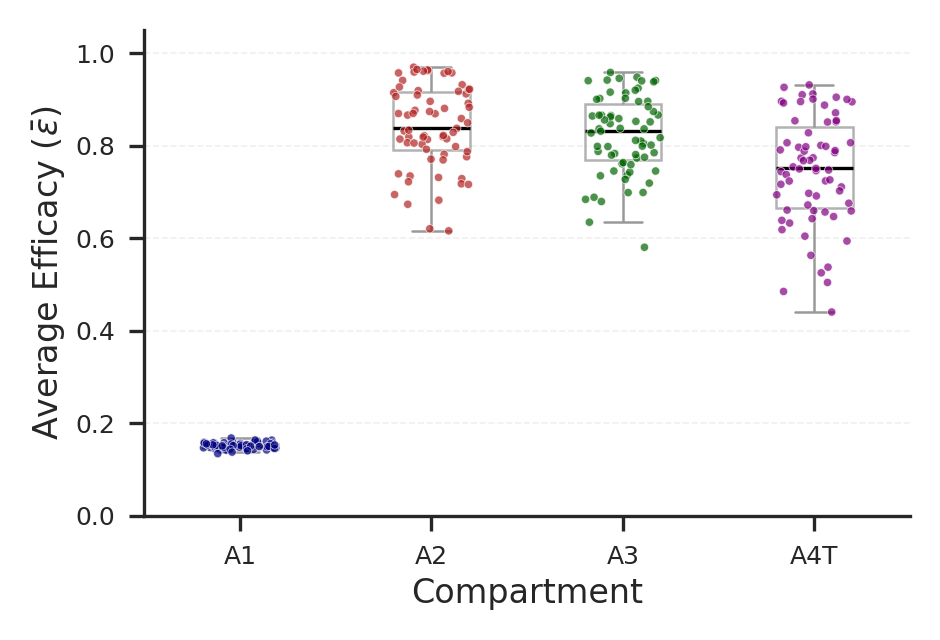

In [ ]:
plot_epsilon_comparison(df_avg_eps)

Figure 3c: Epsilon comparisons across remdesivir, nirmatrelvir (2023 data) and molnupiravir  applied to PLATCOV only

In [ ]:
NIR_df = pd.read_excel('./PLATCOV_NIR_AvgEps.xlsx')
MOL_df = pd.read_excel('./PLATCOV_MOL_AvgEps.xlsx')

In [ ]:
# 1. Filter and Calculate Population Means
# Filter the dataframe to only include compartment A4T
df_a4t_only = df_avg_eps[df_avg_eps['Compartment'].str.contains("A4T", na=False)].copy()

# Group the filtered data by Compartment and calculate the mean of 'Avg_Epsilon'
population_means = df_a4t_only.groupby('Compartment')['Avg_Epsilon'].mean().reset_index()

# Rename the column for clarity
population_means.rename(columns={'Avg_Epsilon': 'Population_Mean_Epsilon'}, inplace=True)

print("Population Mean Epsilon (Compartment A4T Only):")
print(population_means.to_string(index=False))

Population Mean Epsilon (Compartment A4T Only):
Compartment  Population_Mean_Epsilon
        A4T                  0.74659




In [ ]:
# 2. Plotting Function
def plot_cross_drug_efficacy_comparison(df_avg_eps, NIR_df, MOL_df):
    # Target A4T for Remdesivir
    rdv_a4t_raw = df_avg_eps[df_avg_eps["Compartment"].str.contains("A4T", na=False)].copy()

    rdv_df = pd.DataFrame({
        "ID": rdv_a4t_raw["ID"],
        "AvgEpsilon": pd.to_numeric(rdv_a4t_raw["Avg_Epsilon"], errors="coerce"),
        "Antiviral": "Remdesivir"
    })

    nir_df = pd.DataFrame({
        "ID": NIR_df["ID"],
        "AvgEpsilon": pd.to_numeric(NIR_df["AvgEpsilon"], errors="coerce"),
        "Antiviral": "Nirmatrelvir"
    })

    mol_df = pd.DataFrame({
        "ID": MOL_df["ID"],
        "AvgEpsilon": pd.to_numeric(MOL_df["AvgEpsilon"], errors="coerce"),
        "Antiviral": "Molnupiravir"
    })

    combined_df = pd.concat([rdv_df, nir_df, mol_df], ignore_index=True)

    print("\n--- Cohort Statistics Summary ---")
    stats_df = combined_df.groupby("Antiviral")["AvgEpsilon"].describe()
    print(stats_df[["count", "mean", "std", "min", "max"]].to_string())
    print("---------------------------------\n")

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': TINY_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': SMALL_SIZE,
        'legend.fontsize': TINY_SIZE,
        'figure.titlesize': MEDIUM_SIZE,
        'axes.titleweight': 'normal'
    })

    import seaborn as sns
    sns.set_style("ticks")

    fig, ax = plt.subplots(figsize=(2.9, 2.3), dpi=300)

    drug_palette = {
        "Remdesivir": "purple",
        "Nirmatrelvir": "orange",
        "Molnupiravir": "teal"
    }

    sns.boxplot(
        data=combined_df,
        x="Antiviral",
        y="AvgEpsilon",
        color="white",
        width=0.35,
        fliersize=0,
        linewidth=1.0,  # ✅ slightly increased so collapsed lines are visible
        boxprops=dict(alpha=0.6, edgecolor="gray", linewidth=1.0),
        whiskerprops=dict(color="gray", linewidth=0.8),
        capprops=dict(color="gray", linewidth=0.8),
        medianprops=dict(color="black", linewidth=1.2),
        ax=ax,
        zorder=1
    )

    sns.stripplot(
        data=combined_df,
        x="Antiviral",
        y="AvgEpsilon",
        jitter=0.18,
        alpha=0.55,
        size=2.2,
        palette=drug_palette,
        hue="Antiviral",
        legend=False,
        linewidth=0.3,
        edgecolor="white",
        ax=ax,
        zorder=2
    )


    ax.set_ylabel(r"Average Efficacy ($\bar{\epsilon}$)")
    ax.set_xlabel("Antiviral Therapeutic Arm")

    ax.set_ylim(0.0, 1.02)

    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

    sns.despine(ax=ax, offset=5, trim=False)

    plt.tight_layout(pad=0.5)
    plt.show()

    plt.rcdefaults()
    return combined_df


--- Cohort Statistics Summary ---
              count      mean       std       min       max
Antiviral                                                  
Molnupiravir   64.0  0.914854  0.065349  0.707598  0.997342
Nirmatrelvir   58.0  0.897268  0.110640  0.564298  0.996345
Remdesivir     67.0  0.746590  0.117023  0.440083  0.931238
---------------------------------



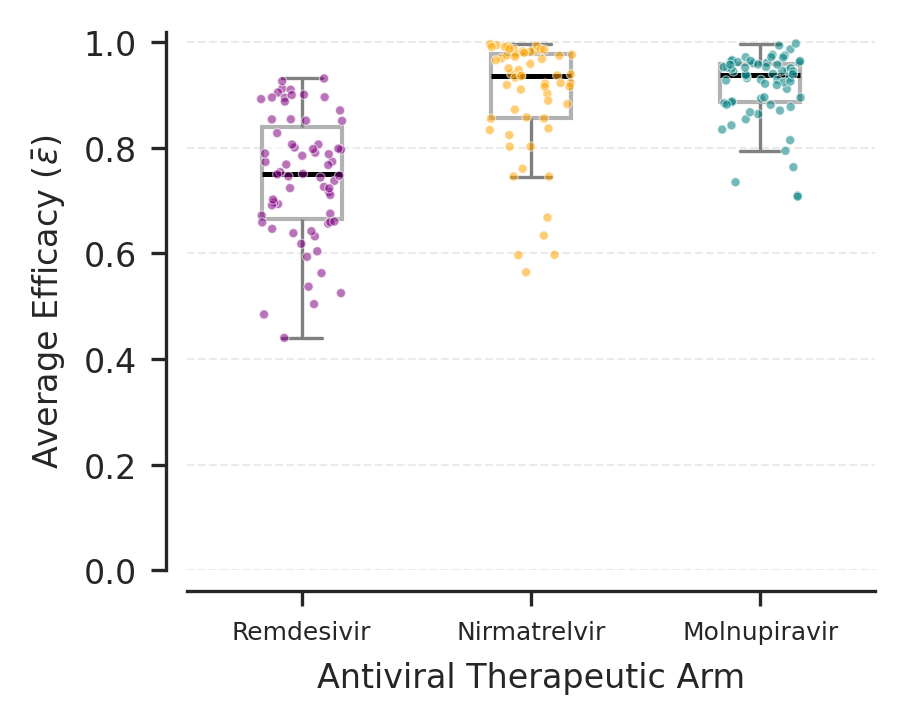

In [ ]:
# Execute the plot
combined_df_result = plot_cross_drug_efficacy_comparison(df_avg_eps, NIR_df, MOL_df)